In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
print("=== LANGKAH 1: MEMUAT DATASET ===")
# Memuat dataset mentah yang telah disediakan
df = pd.read_csv(r'C:\Users\ditia\Downloads\dataset_pelanggan_mentah.csv')
print(f"Dimensi data awal: {df.shape}")

# Menampilkan 5 baris pertama dalam bentuk tabel interaktif
df.head()

=== LANGKAH 1: MEMUAT DATASET ===
Dimensi data awal: (235, 5)


,CustomerID,Usia,Pendapatan_Tahunan_juta,Skor_Pengeluaran_1_100,Kategori_Member
0,CUST-1001,43.0,111.0,58,Premium
1,CUST-1002,36.0,27.0,49,Premium
2,CUST-1003,45.0,78.0,4,Premium
3,CUST-1004,56.0,32.0,48,Regular
4,CUST-1005,35.0,55.0,21,Regular


In [3]:
print("=== LANGKAH 2: CLEANING DATA & PREPROCESSING ===")
# 2.1 Menghapus Data Duplikat
dup_count = df.duplicated().sum()
print(f"Menemukan {dup_count} baris data duplikat. Menghapus duplikat...")
df = df.drop_duplicates()

# 2.2 Penanganan Logika Outlier / Nilai Tidak Valid
df.loc[df['Usia'] > 90, 'Usia'] = np.nan
df.loc[df['Skor_Pengeluaran_1_100'] < 1, 'Skor_Pengeluaran_1_100'] = np.nan
df.loc[df['Pendapatan_Tahunan_juta'] > 200, 'Pendapatan_Tahunan_juta'] = np.nan

# 2.3 Imputasi Missing Values dengan Median
print("Melakukan imputasi nilai kosong (NaN) dengan nilai median...")
df['Usia'] = df['Usia'].fillna(df['Usia'].median()).astype(int)
df['Pendapatan_Tahunan_juta'] = df['Pendapatan_Tahunan_juta'].fillna(df['Pendapatan_Tahunan_juta'].median())
df['Skor_Pengeluaran_1_100'] = df['Skor_Pengeluaran_1_100'].fillna(df['Skor_Pengeluaran_1_100'].median())

# 2.4 Encoding Data Kategorikal
df['Kategori_Member_Encoded'] = df['Kategori_Member'].map({'Regular': 0, 'Premium': 1})
print("Pembersihan selesai. Sisa data bersih:", df.shape[0], "baris.")

=== LANGKAH 2: CLEANING DATA & PREPROCESSING ===
Menemukan 15 baris data duplikat. Menghapus duplikat...
Melakukan imputasi nilai kosong (NaN) dengan nilai median...
Pembersihan selesai. Sisa data bersih: 220 baris.


In [4]:
print("=== LANGKAH 3: FEATURE SCALING ===")
features = ['Usia', 'Pendapatan_Tahunan_juta', 'Skor_Pengeluaran_1_100']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
print("Standardisasi fitur berhasil dilakukan.")

=== LANGKAH 3: FEATURE SCALING ===
Standardisasi fitur berhasil dilakukan.


=== LANGKAH 4: IMPLEMENTASI K-MEANS & METODE ELBOW ===


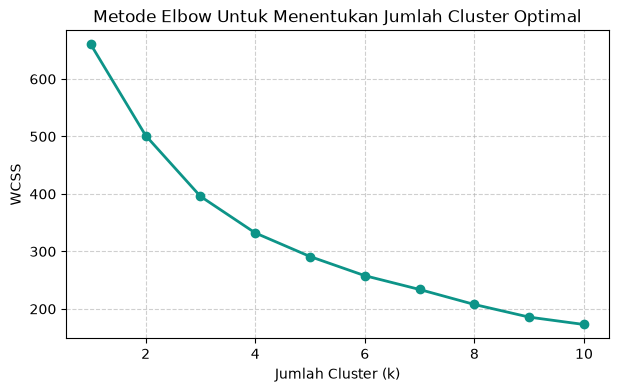

In [5]:
print("=== LANGKAH 4: IMPLEMENTASI K-MEANS & METODE ELBOW ===")
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting Elbow Method
plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker='o', color='#0d9488', linewidth=2)
plt.title('Metode Elbow Untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Di Jupyter, gunakan plt.show() untuk langsung menampilkan grafik di bawah cell

In [6]:
# Menerapkan K-Means dengan K optimal = 4
optimal_k = 4
kmeans_opt = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_opt.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Model K-Means Dilatih dengan K={optimal_k}")
print(f"Silhouette Score untuk K={optimal_k} adalah: {sil:.4f}")

Model K-Means Dilatih dengan K=4
Silhouette Score untuk K=4 adalah: 0.2301


=== LANGKAH 5: VISUALISASI HASIL CLUSTER ===


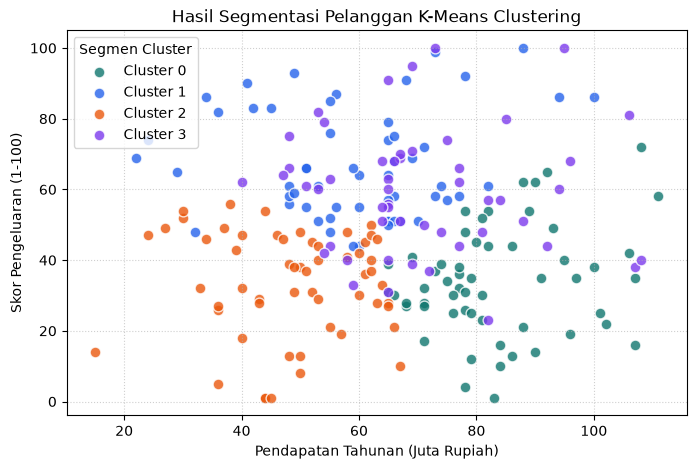

In [7]:
print("=== LANGKAH 5: VISUALISASI HASIL CLUSTER ===")
plt.figure(figsize=(8, 5))
colors = ['#0f766e', '#2563eb', '#ea580c', '#7c3aed']
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Pendapatan_Tahunan_juta'], cluster_data['Skor_Pengeluaran_1_100'], 
                s=60, label=f'Cluster {cluster_id}', color=colors[cluster_id], alpha=0.8, edgecolors='w')

plt.title('Hasil Segmentasi Pelanggan K-Means Clustering')
plt.xlabel('Pendapatan Tahunan (Juta Rupiah)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend(title='Segmen Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [8]:
print("=== LANGKAH 6: ANALISIS PROFILING SETIAP CLUSTER ===")
cluster_profile = df.groupby('Cluster')[features].mean()

# Simpan ke CSV
df.to_csv('dataset_pelanggan_terkluster.csv', index=False)
print("Hasil akhir data berlabel cluster disimpan ke 'dataset_pelanggan_terkluster.csv'.")

# Tampilkan tabel profiling dengan rapi
cluster_profile

=== LANGKAH 6: ANALISIS PROFILING SETIAP CLUSTER ===
Hasil akhir data berlabel cluster disimpan ke 'dataset_pelanggan_terkluster.csv'.


,Usia,Pendapatan_Tahunan_juta,Skor_Pengeluaran_1_100
Cluster,,,
0,43.928571,83.535714,33.964286
1,44.125000,59.178571,67.000000
2,37.035088,48.596491,33.456140
3,24.686275,70.431373,59.450980
